# EDA: Русские отзывы на парфюмы + данные Fragrantica
Датасет: 931 отзыв на 8 парфюмов с рейтингами и нотами

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import os

# Set working directory to project root
if os.path.exists("data"):
    pass  # already at project root
elif os.path.exists("../data"):
    os.chdir("..")

df = pd.read_csv("data/processed/perfumes_merged.csv", encoding="utf-8-sig")
print(f"Shape: {df.shape}")
print(df.dtypes)
print(df.head(2))

Shape: (931, 10)
perfume_name     object
brand            object
rating          float64
votes             int64
top_notes        object
middle_notes     object
base_notes       object
reviewer         object
review_date      object
review_text      object
dtype: object
             perfume_name           brand  rating  votes  \
0  Acqua di Parma Colonia  Acqua di Parma    4.01   1498   
1  Acqua di Parma Colonia  Acqua di Parma    4.01   1498   

                                    top_notes  \
0  Ozonic notes, Bergamot, Orange, Petitgrain   
1  Ozonic notes, Bergamot, Orange, Petitgrain   

                           middle_notes                    base_notes  \
0  Narcissus, Jasmine Sambac, Coriander  White Musk, Cedar, Patchouli   
1  Narcissus, Jasmine Sambac, Coriander  White Musk, Cedar, Patchouli   

            reviewer review_date  \
0      165599 yrok27  14.08.2024   
1  390523 parfuminka  13.07.2024   

                                         review_text  
0  Начну отзыв с

## 1. Базовая статистика

In [2]:
print("=== Парфюмы в датасете ===")
summary = df.groupby("perfume_name").agg(
    brand=("brand", "first"),
    fragrantica_rating=("rating", "first"),
    fragrantica_votes=("votes", "first"),
    n_reviews=("review_text", "count"),
    avg_review_len=("review_text", lambda x: x.str.len().mean().round(0))
).reset_index()
print(summary.to_string())

=== Парфюмы в датасете ===
                perfume_name             brand  fragrantica_rating  fragrantica_votes  n_reviews  avg_review_len
0     Acqua di Parma Colonia    Acqua di Parma                4.01               1498         56           388.0
1              Aspen For Men              Coty                3.92               1842         54           401.0
2               Black Pearls  Elizabeth Taylor                3.82                779         74           461.0
3           By the Fireplace   Maison Margiela                4.21              24439        203           426.0
4  Chanel No 5 Eau de Parfum            Chanel                3.60              11565        208           575.0
5                     Cuoium       Orto Parisi                3.96               3232        201           552.0
6                Dioressence              Dior                4.11                484         79           428.0
7          The One Gentleman     Dolce Gabbana                3.92   

## 2. Количество отзывов по парфюмам

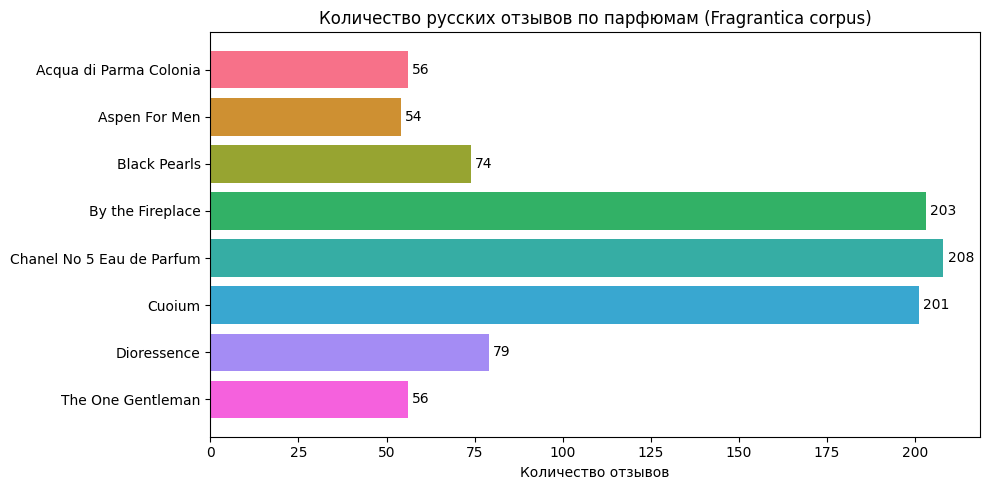

Saved fig_hw3_01_reviews_count.png


In [3]:
fig, ax = plt.subplots(figsize=(10, 5))
colors = sns.color_palette("husl", len(summary))
bars = ax.barh(summary["perfume_name"], summary["n_reviews"], color=colors)
ax.bar_label(bars, padding=3, fontsize=10)
ax.set_xlabel("Количество отзывов")
ax.set_title("Количество русских отзывов по парфюмам (Fragrantica corpus)")
ax.invert_yaxis()
plt.tight_layout()
plt.savefig("notebooks/fig_hw3_01_reviews_count.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved fig_hw3_01_reviews_count.png")

## 3. Рейтинг Fragrantica vs количество отзывов в корпусе

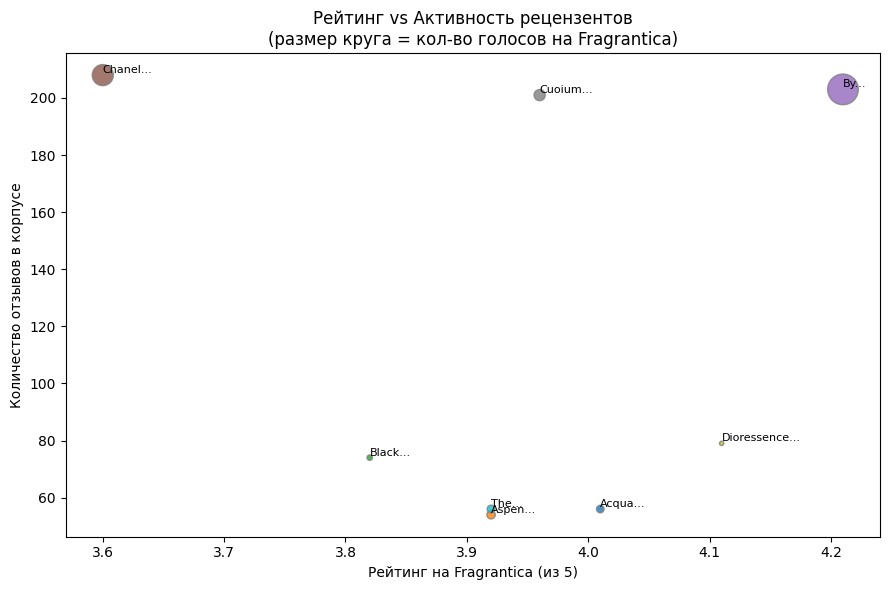

Saved fig_hw3_02_rating_vs_reviews.png


In [4]:
fig, ax = plt.subplots(figsize=(9, 6))
scatter = ax.scatter(
    summary["fragrantica_rating"],
    summary["n_reviews"],
    s=summary["fragrantica_votes"] / 50,
    c=range(len(summary)),
    cmap="tab10",
    alpha=0.8,
    edgecolors="gray"
)
for _, row in summary.iterrows():
    ax.annotate(row["perfume_name"].split()[0] + "...", (row["fragrantica_rating"], row["n_reviews"]),
                fontsize=8, ha="left", va="bottom")
ax.set_xlabel("Рейтинг на Fragrantica (из 5)")
ax.set_ylabel("Количество отзывов в корпусе")
ax.set_title("Рейтинг vs Активность рецензентов\n(размер круга = кол-во голосов на Fragrantica)")
plt.tight_layout()
plt.savefig("notebooks/fig_hw3_02_rating_vs_reviews.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved fig_hw3_02_rating_vs_reviews.png")

## 4. Рейтинги парфюмов (bar chart)

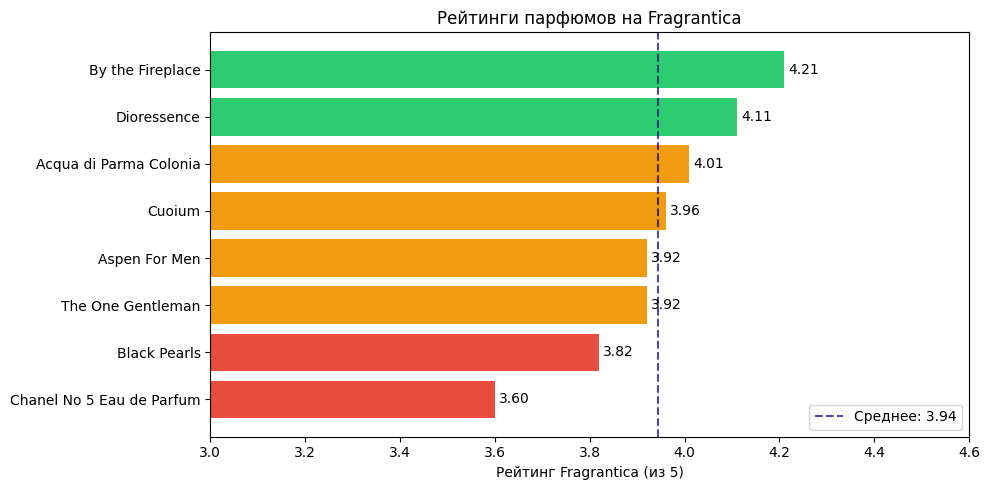

Saved fig_hw3_03_ratings.png


In [5]:
summary_sorted = summary.sort_values("fragrantica_rating", ascending=True)
fig, ax = plt.subplots(figsize=(10, 5))
colors_rating = ["#e74c3c" if r < 3.9 else "#2ecc71" if r >= 4.1 else "#f39c12" for r in summary_sorted["fragrantica_rating"]]
bars = ax.barh(summary_sorted["perfume_name"], summary_sorted["fragrantica_rating"], color=colors_rating)
ax.bar_label(bars, fmt="%.2f", padding=3)
ax.set_xlim(3.0, 4.6)
ax.axvline(x=summary_sorted["fragrantica_rating"].mean(), color="navy", linestyle="--", alpha=0.7, label=f"Среднее: {summary_sorted['fragrantica_rating'].mean():.2f}")
ax.legend()
ax.set_xlabel("Рейтинг Fragrantica (из 5)")
ax.set_title("Рейтинги парфюмов на Fragrantica")
plt.tight_layout()
plt.savefig("notebooks/fig_hw3_03_ratings.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved fig_hw3_03_ratings.png")

## 5. Топ нот (frequency across all perfumes)

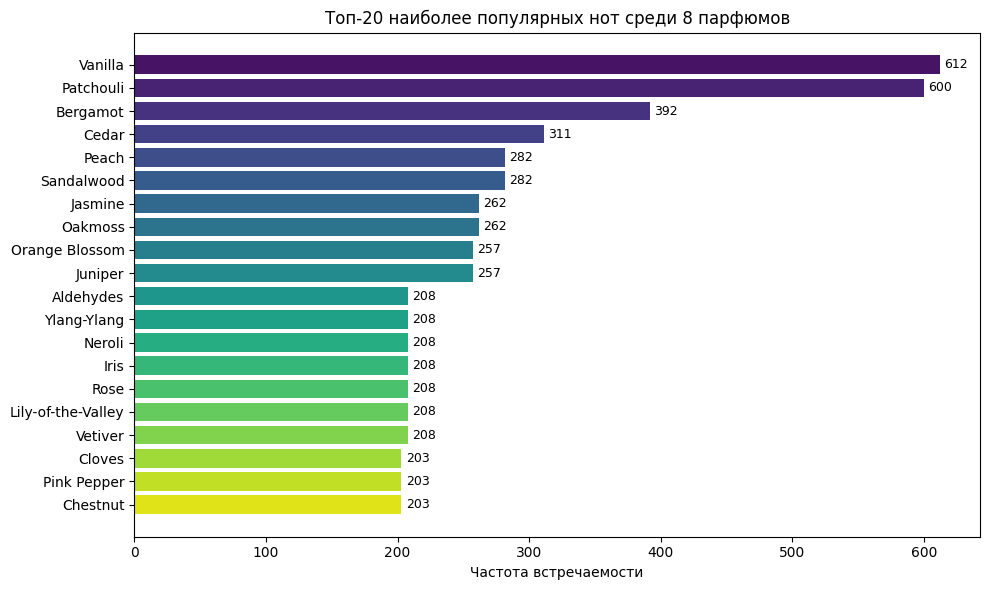

Saved fig_hw3_04_top_notes.png


In [6]:
all_notes = []
for col in ["top_notes", "middle_notes", "base_notes"]:
    for val in df[col].dropna():
        notes = [n.strip() for n in val.split(",") if n.strip()]
        all_notes.extend(notes)

note_counts = Counter(all_notes)
top_notes = note_counts.most_common(20)

fig, ax = plt.subplots(figsize=(10, 6))
notes_names = [n[0] for n in top_notes]
notes_vals = [n[1] for n in top_notes]
colors_notes = sns.color_palette("viridis", len(notes_names))
bars = ax.barh(notes_names[::-1], notes_vals[::-1], color=colors_notes[::-1])
ax.bar_label(bars, padding=3, fontsize=9)
ax.set_xlabel("Частота встречаемости")
ax.set_title("Топ-20 наиболее популярных нот среди 8 парфюмов")
plt.tight_layout()
plt.savefig("notebooks/fig_hw3_04_top_notes.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved fig_hw3_04_top_notes.png")

## 6. Ноты по уровням (top/middle/base)

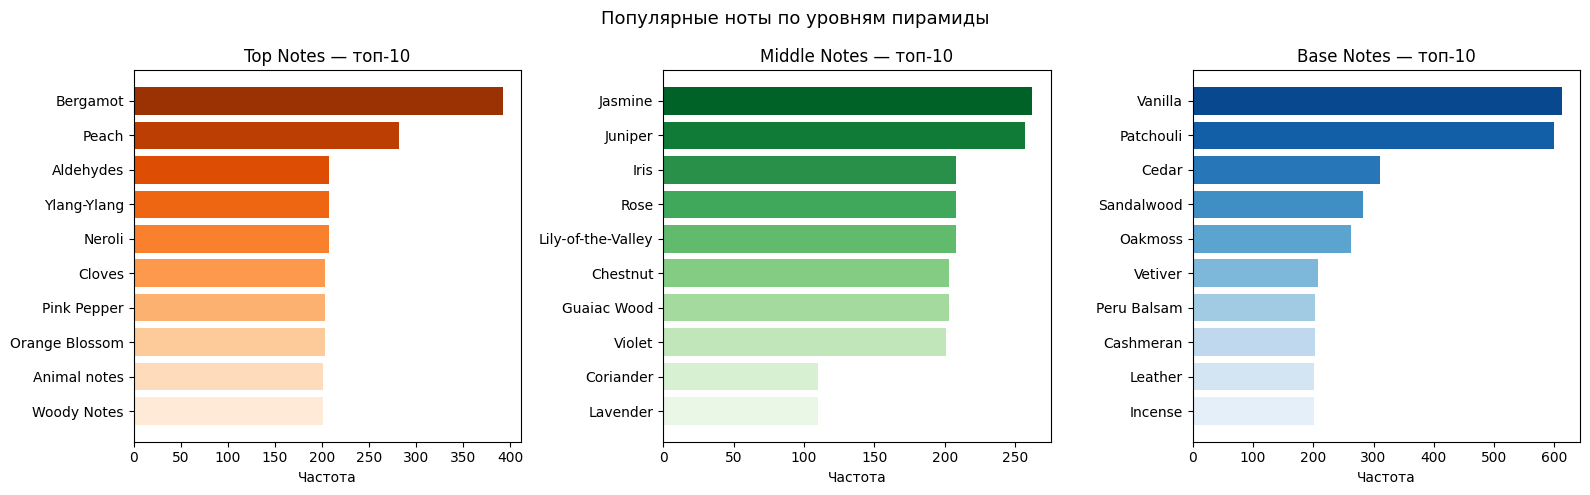

Saved fig_hw3_05_notes_pyramid.png


In [7]:
level_counts = {}
for level, col in [("Top", "top_notes"), ("Middle", "middle_notes"), ("Base", "base_notes")]:
    notes = []
    for val in df[col].dropna():
        notes.extend([n.strip() for n in val.split(",") if n.strip()])
    counter = Counter(notes)
    level_counts[level] = counter

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, (level, counter) in zip(axes, level_counts.items()):
    top = counter.most_common(10)
    names = [t[0] for t in top][::-1]
    vals = [t[1] for t in top][::-1]
    palette = {"Top": "Oranges", "Middle": "Greens", "Base": "Blues"}[level]
    colors_lv = sns.color_palette(palette, len(names))
    ax.barh(names, vals, color=colors_lv)
    ax.set_title(f"{level} Notes — топ-10")
    ax.set_xlabel("Частота")
plt.suptitle("Популярные ноты по уровням пирамиды", fontsize=13)
plt.tight_layout()
plt.savefig("notebooks/fig_hw3_05_notes_pyramid.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved fig_hw3_05_notes_pyramid.png")

## 7. Длина отзывов по парфюмам

C:\Users\denni\AppData\Local\Temp\ipykernel_12924\2924875460.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="review_len", y="perfume_name", order=order,


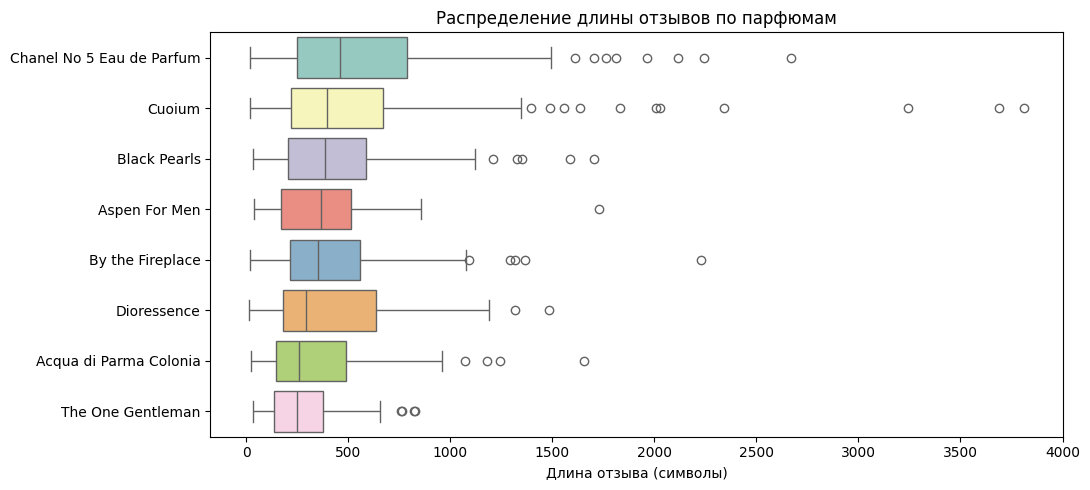

Saved fig_hw3_06_review_length.png


In [8]:
df["review_len"] = df["review_text"].str.len()

fig, ax = plt.subplots(figsize=(11, 5))
order = df.groupby("perfume_name")["review_len"].median().sort_values(ascending=False).index
sns.boxplot(data=df, x="review_len", y="perfume_name", order=order,
            palette="Set3", ax=ax)
ax.set_xlabel("Длина отзыва (символы)")
ax.set_ylabel("")
ax.set_title("Распределение длины отзывов по парфюмам")
plt.tight_layout()
plt.savefig("notebooks/fig_hw3_06_review_length.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved fig_hw3_06_review_length.png")

## 8. Временная динамика отзывов

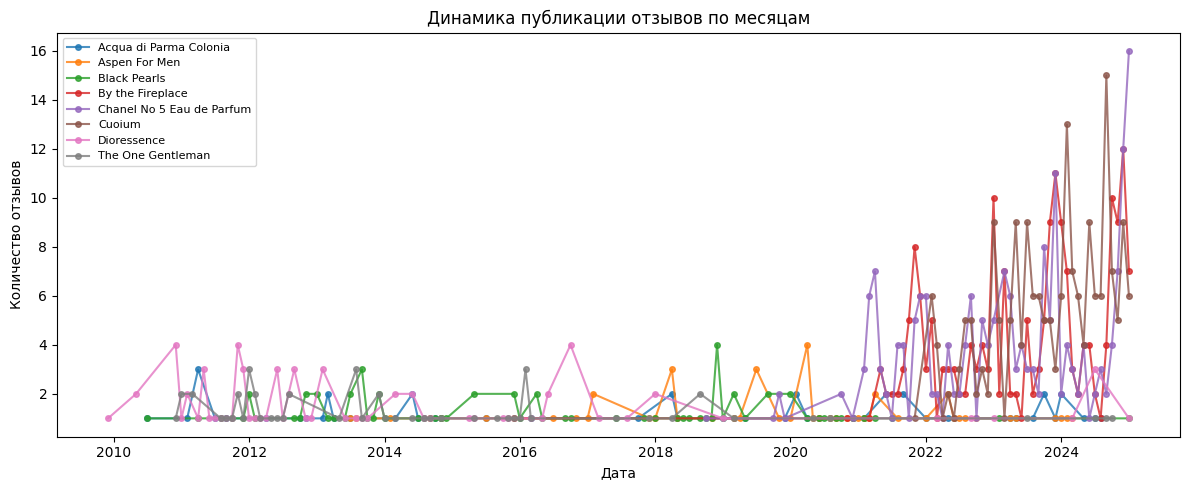

Saved fig_hw3_07_time_dynamics.png


In [9]:
df["review_date"] = pd.to_datetime(df["review_date"], format="%d.%m.%Y", errors="coerce")
df["year_month"] = df["review_date"].dt.to_period("M")
monthly = df.groupby(["year_month", "perfume_name"]).size().reset_index(name="n")
monthly["year_month"] = monthly["year_month"].dt.to_timestamp()

fig, ax = plt.subplots(figsize=(12, 5))
for name, group in monthly.groupby("perfume_name"):
    group_sorted = group.sort_values("year_month")
    ax.plot(group_sorted["year_month"], group_sorted["n"], marker="o", markersize=4, label=name, alpha=0.8)
ax.set_xlabel("Дата")
ax.set_ylabel("Количество отзывов")
ax.set_title("Динамика публикации отзывов по месяцам")
ax.legend(fontsize=8, loc="upper left")
plt.tight_layout()
plt.savefig("notebooks/fig_hw3_07_time_dynamics.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved fig_hw3_07_time_dynamics.png")

## 9. Ноты отдельных парфюмов (heat-like view)

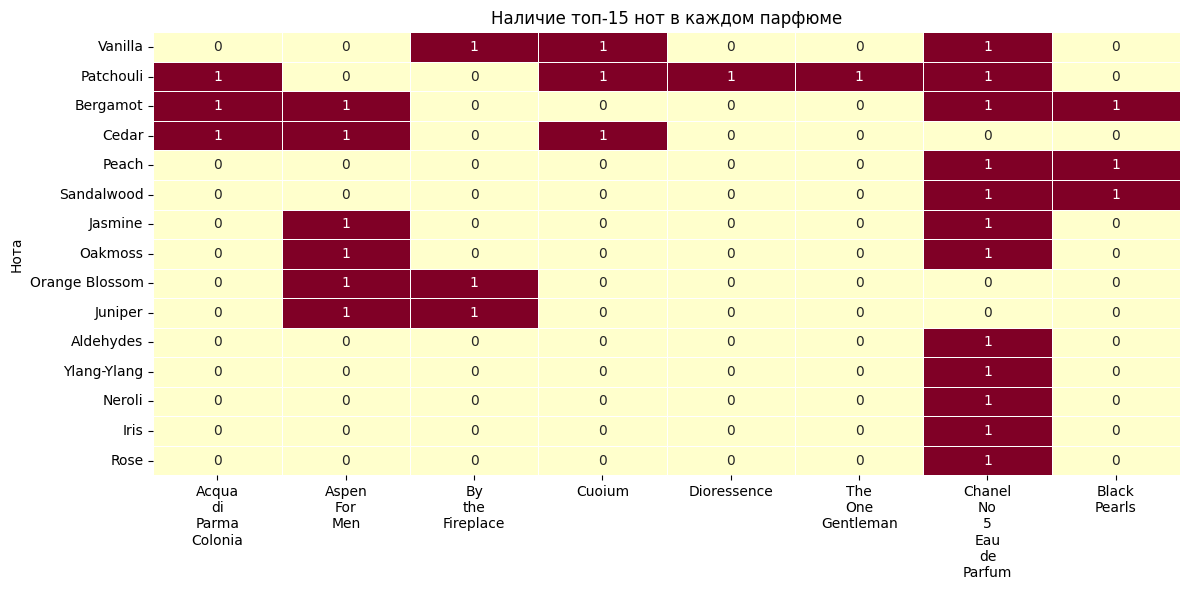

Saved fig_hw3_08_note_heatmap.png


In [10]:
# Create note presence matrix: perfume x note
all_unique_notes = list(set(all_notes))
note_presence = {}
for name in df["perfume_name"].unique():
    row_notes = []
    row = df[df["perfume_name"] == name].iloc[0]
    for col in ["top_notes", "middle_notes", "base_notes"]:
        row_notes.extend([n.strip() for n in str(row[col]).split(",") if n.strip()])
    note_presence[name] = row_notes

# Top 15 most common notes
top15 = [n[0] for n in note_counts.most_common(15)]
matrix = pd.DataFrame(
    {name: [1 if note in notes else 0 for note in top15]
     for name, notes in note_presence.items()},
    index=top15
)

fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(matrix, annot=True, fmt="d", cmap="YlOrRd", ax=ax,
            linewidths=0.5, cbar=False,
            xticklabels=[n.replace(" ", "\n") for n in matrix.columns])
ax.set_title("Наличие топ-15 нот в каждом парфюме")
ax.set_ylabel("Нота")
plt.tight_layout()
plt.savefig("notebooks/fig_hw3_08_note_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved fig_hw3_08_note_heatmap.png")

## 10. Количество нот vs рейтинг

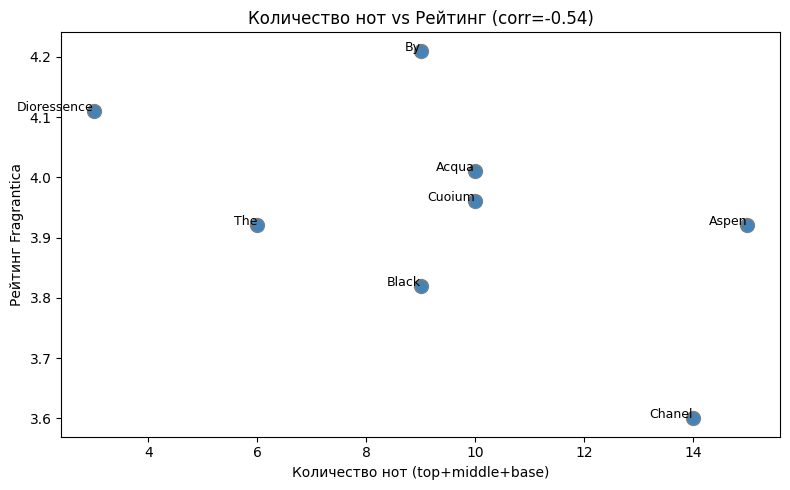

Saved fig_hw3_09_notes_vs_rating.png


In [11]:
summary["total_notes"] = summary["perfume_name"].apply(
    lambda name: len(note_presence.get(name, []))
)

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(summary["total_notes"], summary["fragrantica_rating"], s=100, c="steelblue", edgecolors="gray")
for _, row in summary.iterrows():
    ax.annotate(row["perfume_name"].split()[0], (row["total_notes"], row["fragrantica_rating"]),
                fontsize=9, ha="right")

m, b = pd.Series(summary["total_notes"]).pipe(lambda x: (
    (summary["fragrantica_rating"].corr(x)), x.mean()
))
ax.set_xlabel("Количество нот (top+middle+base)")
ax.set_ylabel("Рейтинг Fragrantica")
ax.set_title(f"Количество нот vs Рейтинг (corr={m:.2f})")
plt.tight_layout()
plt.savefig("notebooks/fig_hw3_09_notes_vs_rating.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved fig_hw3_09_notes_vs_rating.png")

## Итоги EDA

In [12]:
print("\n" + "="*60)
print("ИТОГИ EDA")
print("="*60)
print(f"\nВсего отзывов: {len(df)}")
print(f"Парфюмов: {df['perfume_name'].nunique()}")
print(f"Средний рейтинг: {df['rating'].mean():.2f}")
print(f"Средняя длина отзыва: {df['review_len'].mean():.0f} символов")
print(f"Диапазон дат: {df['review_date'].min().date()} — {df['review_date'].max().date()}")
print(f"\nЛидер по рейтингу: {summary.loc[summary['fragrantica_rating'].idxmax(), 'perfforme_name'] if 'performe_name' in summary else summary.sort_values('fragrantica_rating', ascending=False).iloc[0]['perfume_name']} ({summary['fragrantica_rating'].max():.2f})")
print(f"Самый обсуждаемый: {summary.sort_values('n_reviews', ascending=False).iloc[0]['perfume_name']} ({summary['n_reviews'].max()} отзывов)")
print(f"Самый популярный на Fragrantica: {summary.sort_values('fragrantica_votes', ascending=False).iloc[0]['perfume_name']} ({summary['fragrantica_votes'].max():,.0f} голосов)")
print(f"\nНаиболее частая нота: {note_counts.most_common(1)[0][0]} ({note_counts.most_common(1)[0][1]} парфюмов)")
print(f"Уникальных нот всего: {len(set(all_notes))}")
print("\nГенерация завершена!")


ИТОГИ EDA

Всего отзывов: 931
Парфюмов: 8
Средний рейтинг: 3.93
Средняя длина отзыва: 478 символов
Диапазон дат: 2009-12-15 — 2025-01-26

Лидер по рейтингу: By the Fireplace (4.21)
Самый обсуждаемый: Chanel No 5 Eau de Parfum (208 отзывов)
Самый популярный на Fragrantica: By the Fireplace (24,439 голосов)

Наиболее частая нота: Vanilla (612 парфюмов)
Уникальных нот всего: 55

Генерация завершена!
